In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
zmap = {1: "08_11", 2: "11_16"}
regions = ["NGC", "SGC"]

load paper data

In [3]:
paper_data = {}

for i, z in zmap.items():
    dfs = {
        name: pd.read_csv(f"/data/honke/corr_clustering/desi/ell0_{name}_{z}.csv", header=None)
        for name in ["line", "center", "upper", "lower"]
    }

    for df in dfs.values():
        df.columns = ["x", "y"]

    cen = dfs["center"]
    up  = dfs["upper"]
    low = dfs["lower"]

    paper_data[i] = {
        "x": cen["x"],
        "y": cen["y"],
        "yerr_up": up["y"] - cen["y"],
        "yerr_lo": cen["y"] - low["y"],
        "line": dfs["line"],
    }

err data by ximo_pycorr.py

In [11]:
cov = {}
wD = {}
s = {}
err = {}

for r in regions:
    cov[r] = {}
    wD[r] = {}
    s[r] = {}
    
    for i in [1, 2]:
        with np.load(f"/data/honke/corr_clustering/xi/xi0_{r}_z{zmap[i]}_jk_v3.npz") as d:
            cov[r][i] = d["cov"]
            wD[r][i]  = d["wD_tot"]
            s[r][i] = d["s"]

for i in [1, 2]:
    w_tot = wD["NGC"][i] + wD["SGC"][i]

    cov_NS = (
        wD["NGC"][i]**2 * cov["NGC"][i]
        + wD["SGC"][i]**2 * cov["SGC"][i]
    ) / (w_tot**2)

    err[i] = np.sqrt(np.diag(cov_NS))

caliculate Landy-Szalay

In [12]:
DD = {}
DR = {}
RR = {}
wD = {}
wR = {}

for i in [1, 2]:
    z = zmap[i]

    DD[i] = {}
    DR[i] = {}
    RR[i] = {}
    wD[i] = {}
    wR[i] = {}

    for r in regions:
        DD[i][r] = np.load(f"/data/honke/corr_clustering/counts_xyz/DD_{r}_{z}_v3.npy")
        DR[i][r] = np.load(f"/data/honke/corr_clustering/counts_xyz/DR_{r}_{z}_v3.npy")
        RR[i][r] = np.load(f"/data/honke/corr_clustering/counts_xyz/RR_{r}_{z}_v3.npy")

        wD[i][r] = np.load(f"/data/honke/corr_clustering/counts_xyz/wD_{r}_{z}_v3.npy")
        wR[i][r] = np.load(f"/data/honke/corr_clustering/counts_xyz/wR_{r}_{z}_v3.npy")

In [13]:
DDw = {}
DRw = {}
RRw = {}

DDw_NS = {}
DRw_NS = {}
RRw_NS = {}

for i in [1, 2]:
    DDw[i] = {}
    DRw[i] = {}
    RRw[i] = {}

    for r in regions:
        DDw[i][r] = DD[i][r]["npairs"] * DD[i][r]["weightavg"]
        DRw[i][r] = DR[i][r]["npairs"] * DR[i][r]["weightavg"]
        RRw[i][r] = RR[i][r]["npairs"] * RR[i][r]["weightavg"]

    DDw_NS[i] = DDw[i]["NGC"] + DDw[i]["SGC"]
    DRw_NS[i] = DRw[i]["NGC"] + DRw[i]["SGC"]
    RRw_NS[i] = RRw[i]["NGC"] + RRw[i]["SGC"]

In [14]:
SD = {}
SR = {}
DDn = {}
DRn = {}
RRn = {}
xi_smu = {}
rr_weight = {}
xi_smu_NS = {}
xi_smu_2d_NS = {}
xi_mono_NS = {}

for i in [1, 2]:
    SD[i] = {}
    SR[i] = {}
    DDn[i] = {}
    DRn[i] = {}
    RRn[i] = {}
    xi_smu[i] = {}
    rr_weight[i] = {}

    for r in regions:
        SD[i][r] = np.sum(wD[i][r])
        SR[i][r] = np.sum(wR[i][r])

    for r in regions:
        DDn[i][r] = DDw[i][r] / (SD[i][r]**2 - np.sum(wD[i][r]**2))
        DRn[i][r] = DRw[i][r] / (SD[i][r] * SR[i][r])
        RRn[i][r] = RRw[i][r] / (SR[i][r]**2 - np.sum(wR[i][r]**2))

        xi_smu[i][r] = (DDn[i][r] - 2*DRn[i][r] + RRn[i][r]) / RRn[i][r]

        rr_weight[i][r] = SR[i][r]**2 - np.sum(wR[i][r]**2)

    xi_smu_NS[i] = (
        rr_weight[i]["NGC"] * xi_smu[i]["NGC"]
        + rr_weight[i]["SGC"] * xi_smu[i]["SGC"]
    ) / (rr_weight[i]["NGC"] + rr_weight[i]["SGC"])

    xi_smu_2d_NS[i] = xi_smu_NS[i].reshape(45, 20)
    xi_mono_NS[i] = xi_smu_2d_NS[i].mean(axis=1)

plot

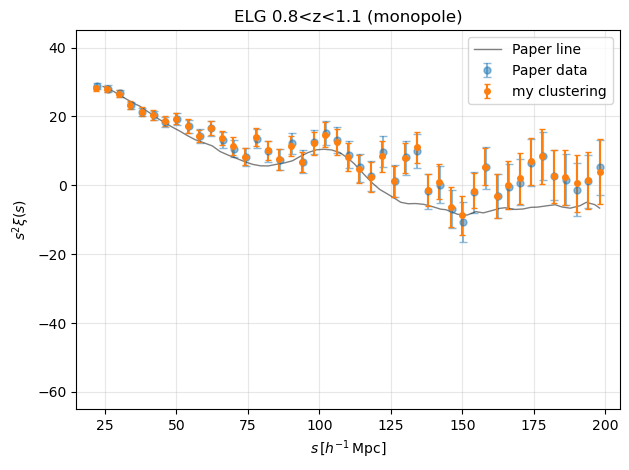

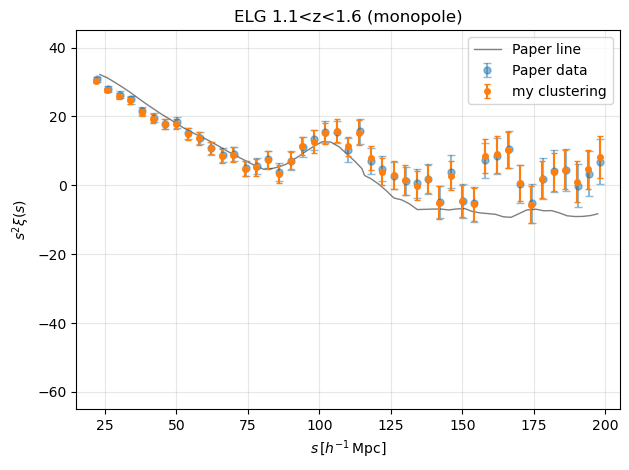

In [15]:
fig_titles = {
    1: "ELG 0.8<z<1.1 (monopole)",
    2: "ELG 1.1<z<1.6 (monopole)",
}

for i in [1, 2]:
    fig, ax = plt.subplots()

    ax.errorbar(
        paper_data[i]["x"], paper_data[i]["y"],
        yerr=[paper_data[i]["yerr_lo"], paper_data[i]["yerr_up"]],
        fmt="o", ms=5, capsize=3, alpha=0.5,
        label="Paper data"
    )

    ax.plot(
        paper_data[i]["line"]["x"], paper_data[i]["line"]["y"],
        lw=1, color="black", alpha=0.5,
        label="Paper line"
    )

    ax.errorbar(
        s["NGC"][i], s["NGC"][i]**2 * xi_mono_NS[i],
        yerr=s["NGC"][i]**2 * err[i],
        fmt="o", ms=4, capsize=2,
        label="my clustering"
    )

    ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
    ax.set_ylabel(r"$s^2\xi(s)$")
    ax.set_xlim(15, 205)
    ax.set_ylim(-65, 45)
    ax.set_xticks(np.arange(25, 201, 25))
    ax.set_yticks(np.arange(-60, 41, 20))
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_title(fig_titles[i])
    plt.tight_layout()

plt.show()

delta plot

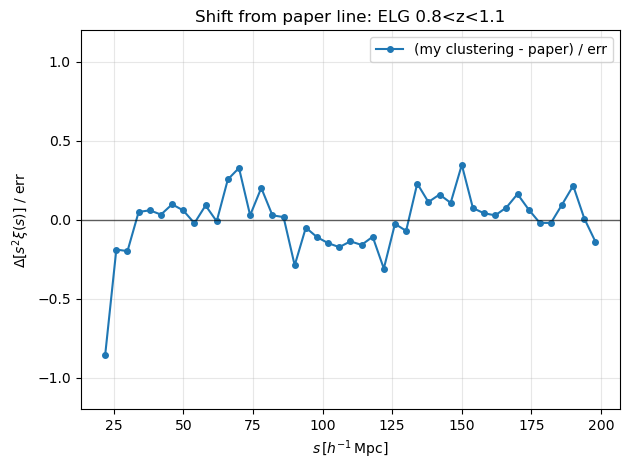

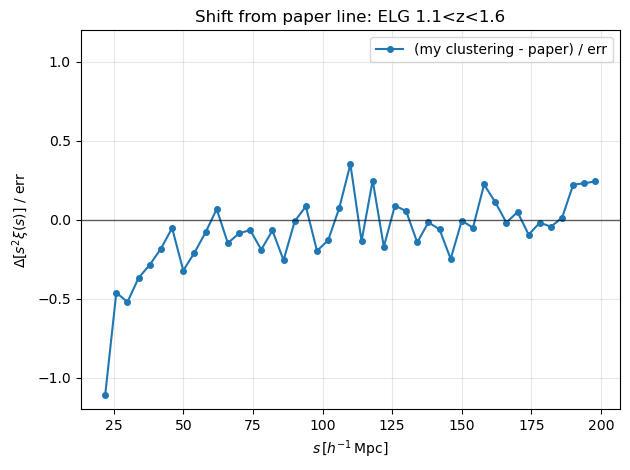

In [16]:
fig_titles_delta = {
    1: "Shift from paper line: ELG 0.8<z<1.1",
    2: "Shift from paper line: ELG 1.1<z<1.6",
}

for i in [1, 2]:
    
    delta = s["NGC"][i]**2 * xi_mono_NS[i] - paper_data[i]["y"]
    delta /= (s["NGC"][i]**2 * err[i])

    fig, ax = plt.subplots()

    ax.plot(
        s["NGC"][i], delta, "o-", ms=4,
        label="(my clustering - paper) / err"
    )   
    ax.axhline(0, color="black", lw=1, alpha=0.6)
    ax.set_xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
    ax.set_ylabel(r"$\Delta[s^2\xi(s)]$ / err")
    ax.set_ylim(-1.2, 1.2)
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_title(fig_titles_delta[i])
    plt.tight_layout()

plt.show()